In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
dup = pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/genome-annotation/biser/hifiasm-041425/segdup_output.bedpe",
    sep="\t",
    header=None,
    names=["chr1", "start1", "end1", "chr2", "start2", "end2","reference","score","strand1","strand2","max_len","aln_len","cigar","optional"]
)

In [3]:
## Check if biser has reciprocal output or not
# Assuming your dataframe has columns like: chr1, start1, end1, chr2, start2, end2
def has_reciprocal_duplicates(df):
    # Create a normalized representation where pairs are always sorted
    normalized_pairs = []
    for _, row in df.iterrows():
        # Create a tuple representation that's order-independent
        pair = tuple(sorted([(row['chr1'], row['start1'], row['end1']), 
                           (row['chr2'], row['start2'], row['end2'])]))
        normalized_pairs.append(pair)
    
    # Check for duplicates in the normalized list
    unique_pairs = set(normalized_pairs)
    
    print(f"Total links in dataframe: {len(df)}")
    print(f"Unique normalized pairs: {len(unique_pairs)}")
    
    if len(normalized_pairs) != len(unique_pairs):
        print("❌ WARNING: Reciprocal duplicates found!")
        return True
    else:
        print("✅ No reciprocal duplicates found")
        return False

# Run the check
has_reciprocal_duplicates(dup)

Total links in dataframe: 208156
Unique normalized pairs: 203532
❌ WARNING: Reciprocal duplicates found!


True

In [4]:
import pandas as pd

def examine_reciprocal_duplicates(df, num_examples=5):
    """
    Examine the first few reciprocal duplicate pairs in detail
    """
    seen_pairs = set()
    reciprocal_examples = []
    
    print("Looking for reciprocal duplicates...")
    for idx, row in df.iterrows():
        pair1 = (row['chr1'], row['start1'], row['end1'], row['chr2'], row['start2'], row['end2'])
        pair2 = (row['chr2'], row['start2'], row['end2'], row['chr1'], row['start1'], row['end1'])
        
        # Check if we've seen the reciprocal
        if pair2 in seen_pairs:
            reciprocal_examples.append({
                'index': idx,
                'current_pair': pair1,
                'reciprocal_of': pair2
            })
            # Stop once we have enough examples
            if len(reciprocal_examples) >= num_examples:
                break
        else:
            seen_pairs.add(pair1)
    
    # Display the examples
    print(f"\n=== First {len(reciprocal_examples)} Reciprocal Duplicate Examples ===")
    for i, example in enumerate(reciprocal_examples, 1):
        print(f"\n--- Example {i} ---")
        print(f"Duplicate at index {example['index']}:")
        print(f"  This entry:    {example['current_pair'][0]}:{example['current_pair'][1]}-{example['current_pair'][2]} ↔ {example['current_pair'][3]}:{example['current_pair'][4]}-{example['current_pair'][5]}")
        print(f"  Reciprocal of: {example['reciprocal_of'][0]}:{example['reciprocal_of'][1]}-{example['reciprocal_of'][2]} ↔ {example['reciprocal_of'][3]}:{example['reciprocal_of'][4]}-{example['reciprocal_of'][5]}")
    
    return reciprocal_examples

# Also let's check if there are any exact same pairs (not just reciprocal)
def check_exact_duplicates(df):
    """Check for exact same pairs (same order)"""
    exact_duplicates = df.duplicated(subset=['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']).sum()
    print(f"\nExact duplicates (same order): {exact_duplicates}")
    return exact_duplicates

# Run the examination
examples = examine_reciprocal_duplicates(dup, num_examples=5)
exact_dups = check_exact_duplicates(dup)

# Let's also see the distribution - are these all truly identical or just very similar?
print(f"\n=== Summary ===")
print(f"Total links: {len(dup)}")
print(f"Unique normalized pairs: {len(set(tuple(sorted([(r['chr1'], r['start1'], r['end1']), (r['chr2'], r['start2'], r['end2'])])) for _, r in dup.iterrows()))}")
print(f"Reciprocal duplicates found: {len(dup) - len(set(tuple(sorted([(r['chr1'], r['start1'], r['end1']), (r['chr2'], r['start2'], r['end2'])])) for _, r in dup.iterrows()))}")

Looking for reciprocal duplicates...

=== First 5 Reciprocal Duplicate Examples ===

--- Example 1 ---
Duplicate at index 29:
  This entry:    chr1:2196575-2197503 ↔ chr1:2191520-2192511
  Reciprocal of: chr1:2191520-2192511 ↔ chr1:2196575-2197503

--- Example 2 ---
Duplicate at index 32:
  This entry:    chr1:2200658-2205912 ↔ chr1:2200151-2204987
  Reciprocal of: chr1:2200151-2204987 ↔ chr1:2200658-2205912

--- Example 3 ---
Duplicate at index 34:
  This entry:    chr1:2210715-2211706 ↔ chr1:2191514-2197501
  Reciprocal of: chr1:2191514-2197501 ↔ chr1:2210715-2211706

--- Example 4 ---
Duplicate at index 458:
  This entry:    chr1:130383832-130406854 ↔ chr1:130353993-130361699
  Reciprocal of: chr1:130353993-130361699 ↔ chr1:130383832-130406854

--- Example 5 ---
Duplicate at index 459:
  This entry:    chr1:130388012-130398837 ↔ chr1:130380356-130382830
  Reciprocal of: chr1:130380356-130382830 ↔ chr1:130388012-130398837

Exact duplicates (same order): 0

=== Summary ===
Total links

KeyboardInterrupt: 

In [ ]:
def remove_reciprocal_duplicates(df):
    """
    Remove reciprocal duplicates from BISER dataframe, keeping only one representation of each pair
    """
    seen_pairs = set()
    mask_to_keep = []
    
    for idx, row in df.iterrows():
        # Create both representations
        pair_forward = (row['chr1'], row['start1'], row['end1'], row['chr2'], row['start2'], row['end2'])
        pair_reverse = (row['chr2'], row['start2'], row['end2'], row['chr1'], row['start1'], row['end1'])
        
        # Create normalized version (sorted to be order-independent)
        normalized_pair = tuple(sorted([(row['chr1'], row['start1'], row['end1']), 
                                      (row['chr2'], row['start2'], row['end2'])]))
        
        # Keep this row only if we haven't seen the normalized pair before
        if normalized_pair not in seen_pairs:
            seen_pairs.add(normalized_pair)
            mask_to_keep.append(True)
        else:
            mask_to_keep.append(False)
    
    cleaned_df = df[mask_to_keep].reset_index(drop=True)
    
    print(f"Original dataframe: {len(df)} rows")
    print(f"Cleaned dataframe: {len(cleaned_df)} rows")
    print(f"Removed {len(df) - len(cleaned_df)} reciprocal duplicates")
    
    return cleaned_df

# Clean your dataframe
cleaned_biser_df = remove_reciprocal_duplicates(dup)

# Verify the cleaning worked
def verify_cleaning(df):
    normalized_pairs = set()
    for _, row in df.iterrows():
        pair = tuple(sorted([(row['chr1'], row['start1'], row['end1']), 
                           (row['chr2'], row['start2'], row['end2'])]))
        normalized_pairs.add(pair)
    
    print(f"Verification - Unique pairs in cleaned data: {len(normalized_pairs)}")
    print(f"Verification - Total rows in cleaned data: {len(df)}")
    print("✅ Cleaning successful!" if len(normalized_pairs) == len(df) else "❌ Cleaning failed")

verify_cleaning(cleaned_biser_df)

In [ ]:
cleaned_biser_df.to_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/genome-annotation/biser/hifiasm-041425/segdup_output_duplicateLinkRemoved.bedpe",
    sep="\t",
    header=None,
    # names=["chr1", "start1", "end1", "chr2", "start2", "end2","reference","score","strand1","strand2","max_len","aln_len","cigar","optional"]
)

In [5]:
cleaned_biser_df=pd.read_csv(
    "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/genome-annotation/biser/hifiasm-041425/segdup_output_duplicateLinkRemoved.bedpe",
    sep="\t",
    header=None,
    names=["chr1", "start1", "end1", "chr2", "start2", "end2","reference","score","strand1","strand2","max_len","aln_len","cigar","optional"]
)

In [6]:
# dup["Conservation_of_segdup"] = 100-dup["score"]
dup = cleaned_biser_df
dup = dup[~(dup["chr1"].str.contains("seq"))&~(dup["chr2"].str.contains("seq"))]
dup["dup_type"] = np.where(dup["chr1"] == dup["chr2"], 
                           "Intrachromosomal", 
                           "Interchromosomal")

/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_3851152/2443226288.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dup["dup_type"] = np.where(dup["chr1"] == dup["chr2"],


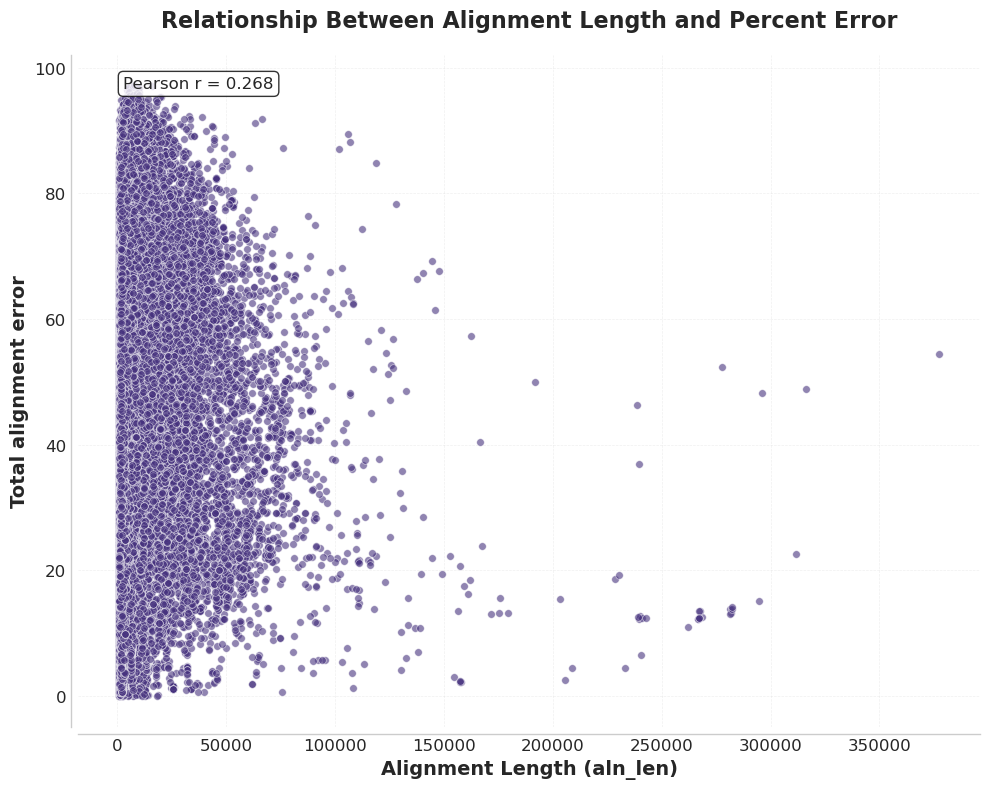

In [7]:

# Set style for scientific publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Create the figure
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create scatterplot with transparency to handle overplotting
scatter = ax.scatter(dup['aln_len'], dup['score'], 
                    alpha=0.6, s=30, edgecolors='w', linewidth=0.5)

# Add labels and title
ax.set_xlabel('Alignment Length (aln_len)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total alignment error', fontsize=14, fontweight='bold')
ax.set_title('Relationship Between Alignment Length and Percent Error', 
             fontsize=16, fontweight='bold', pad=20)
# ax.set_xscale("log")

# Improve tick formatting
ax.tick_params(axis='both', which='major', labelsize=12)
# ax.ticklabel_format(style='plain')  # Prevent scientific notation

# Remove top and right spines for publication format
sns.despine(top=True, right=True, offset=5, trim=False)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Add correlation coefficient
correlation = dup['aln_len'].corr(dup['score'])
ax.text(0.05, 0.95, f'Pearson r = {correlation:.3f}', 
        transform=ax.transAxes, fontsize=12, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

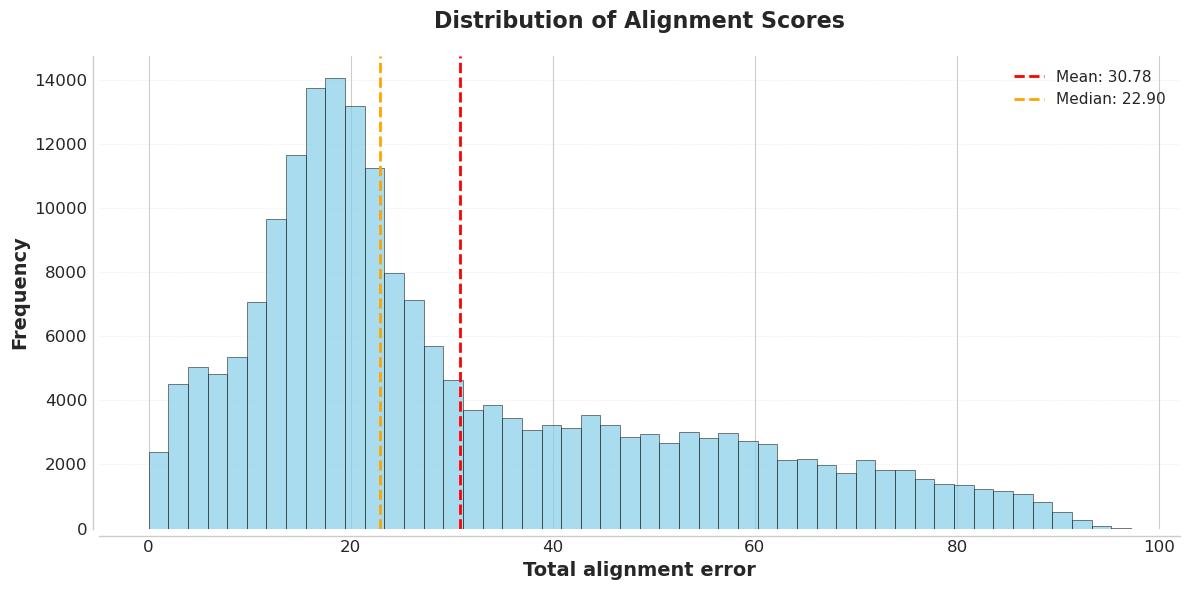

In [8]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Create histogram
n, bins, patches = ax.hist(dup['score'], bins=50, alpha=0.7, color='skyblue', 
                           edgecolor='black', linewidth=0.5)

# Formatting
ax.set_xlabel('Total alignment error', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Alignment Scores', fontsize=16, fontweight='bold', pad=20)

# Improve ticks
ax.tick_params(axis='both', which='major', labelsize=12)

# Remove spines
sns.despine(top=True, right=True, offset=5)

# Add grid
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.5)

# Add statistics
mean_score = dup['score'].mean()
median_score = dup['score'].median()
ax.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.2f}')
ax.axvline(median_score, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_score:.2f}')

ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

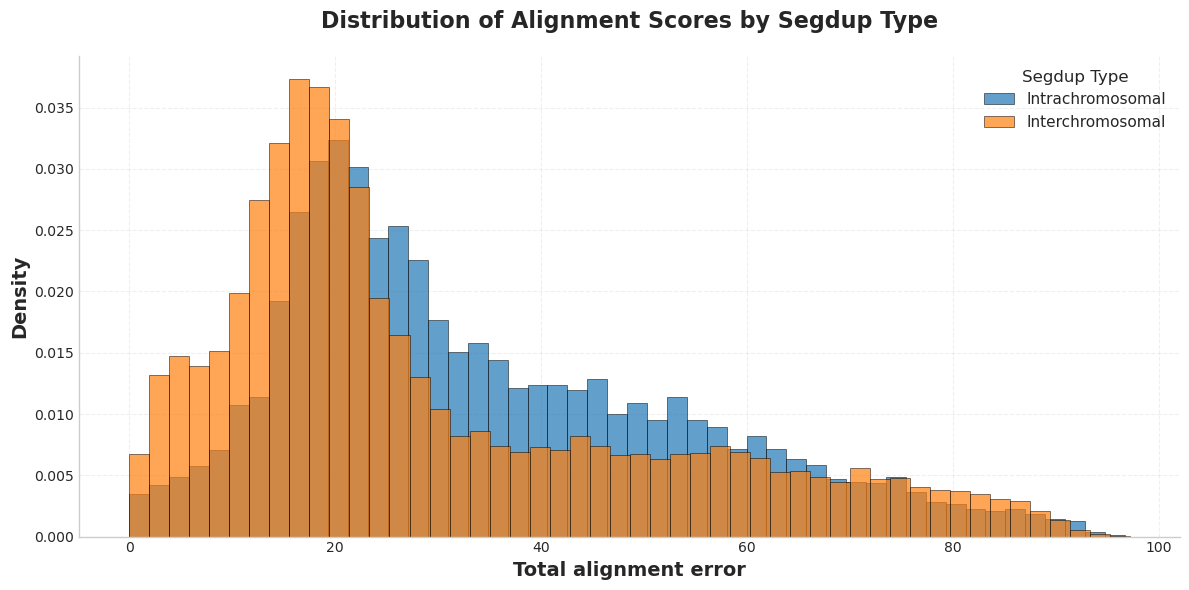

In [9]:
# Manual plotting for complete control over colors and legend
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Define colors and subsets
colors = {'Intrachromosomal': '#1f77b4', 'Interchromosomal': '#ff7f0e'}
intra = dup[dup['dup_type'] == 'Intrachromosomal']
inter = dup[dup['dup_type'] == 'Interchromosomal']

# Plot each type separately
ax.hist(intra['score'], bins=50, alpha=0.7, color=colors['Intrachromosomal'], 
        label='Intrachromosomal', density=True, edgecolor='black', linewidth=0.5)
ax.hist(inter['score'], bins=50, alpha=0.7, color=colors['Interchromosomal'], 
        label='Interchromosomal', density=True, edgecolor='black', linewidth=0.5)

# Formatting
ax.set_xlabel('Total alignment error', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Alignment Scores by Segdup Type', fontsize=16, fontweight='bold', pad=20)

# Legend with explicit colors
ax.legend(title='Segdup Type', title_fontsize=12, fontsize=11)

# Remove spines and add grid
sns.despine(top=True, right=True)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

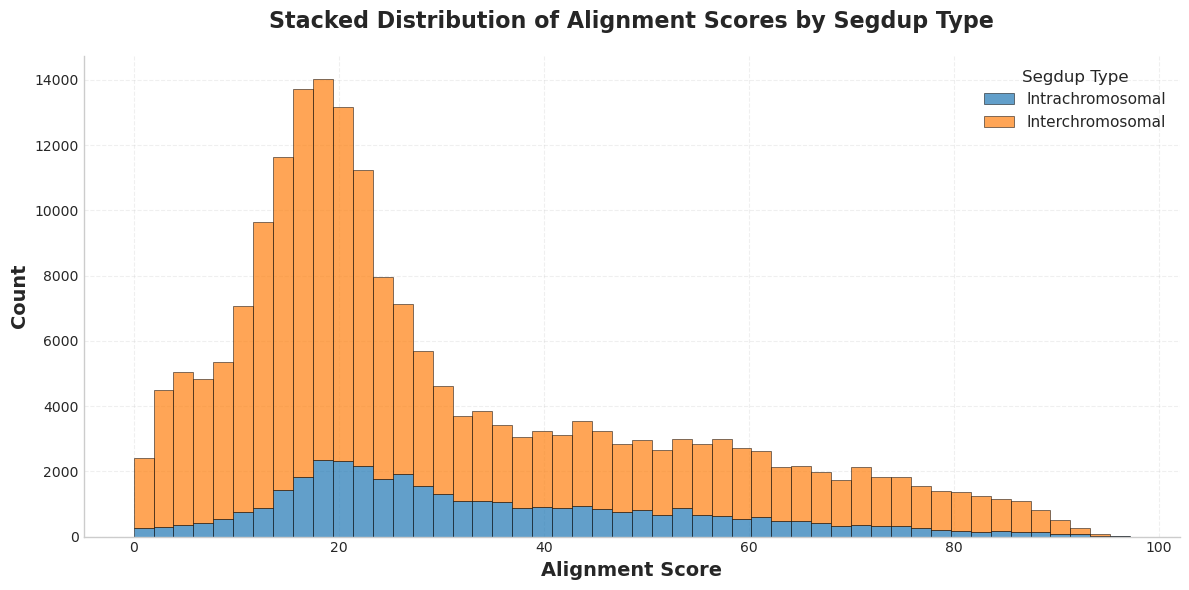

In [10]:
# Manual plotting for stacked histogram
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Define colors and subsets
colors = {'Intrachromosomal': '#1f77b4', 'Interchromosomal': '#ff7f0e'}
intra = dup[dup['dup_type'] == 'Intrachromosomal']
inter = dup[dup['dup_type'] == 'Interchromosomal']

# Plot stacked histogram
ax.hist([intra['score'], inter['score']], bins=50, stacked=True, 
        alpha=0.7, color=[colors['Intrachromosomal'], colors['Interchromosomal']], 
        label=['Intrachromosomal', 'Interchromosomal'], 
        edgecolor='black', linewidth=0.5)

# Formatting
ax.set_xlabel('Alignment Score', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=14, fontweight='bold')
ax.set_title('Stacked Distribution of Alignment Scores by Segdup Type', fontsize=16, fontweight='bold', pad=20)

# Legend with explicit colors
ax.legend(title='Segdup Type', title_fontsize=12, fontsize=11)

# Remove spines and add grid
sns.despine(top=True, right=True)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()